In [1]:
# ==============================
# Customer Segmentation Project
# Step 1 : Import Libraries
# ==============================

# Pandas -> CSV file read karne aur table (DataFrame) handle karne ke liye
import pandas as pd

# NumPy -> Numerical calculations aur arrays ke liye
import numpy as np

# Matplotlib -> Basic graphs banane ke liye
import matplotlib.pyplot as plt

# Seaborn -> Beautiful statistical graphs ke liye
import seaborn as sns

# StandardScaler -> Features ko same scale par lane ke liye
from sklearn.preprocessing import StandardScaler

# KMeans -> Clustering Algorithm
from sklearn.cluster import KMeans

# Warning messages hide karne ke liye
import warnings
warnings.filterwarnings('ignore')

In [2]:
import zipfile
import os

zip_path = "archive.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [3]:
import os

print(os.listdir(extract_path))

['Mall_Customers.csv']


In [4]:
file_path = extract_path + "/Mall_Customers.csv"

df = pd.read_csv(file_path)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.shape

(200, 5)

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [12]:
# Sirf numerical columns select karna
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
numeric_df.corr()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


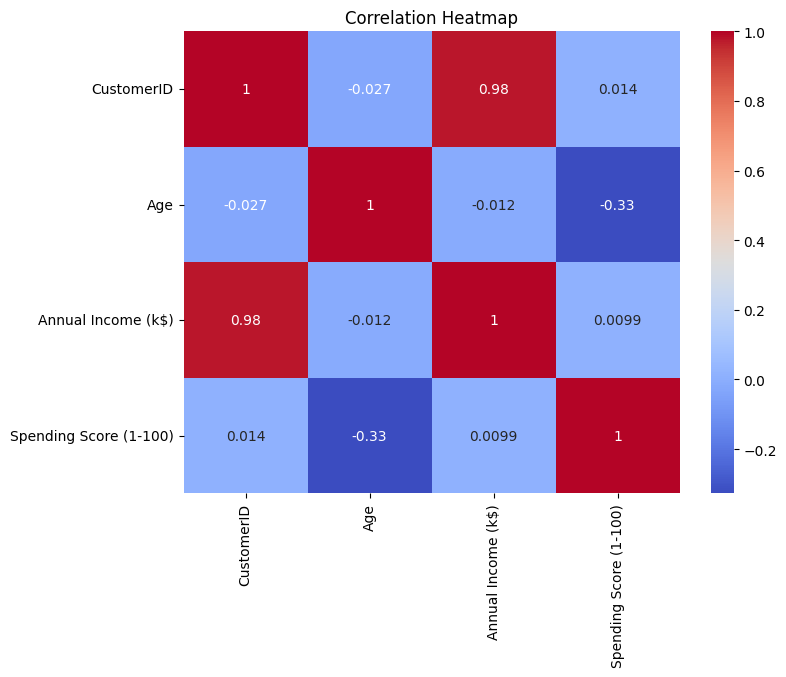

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

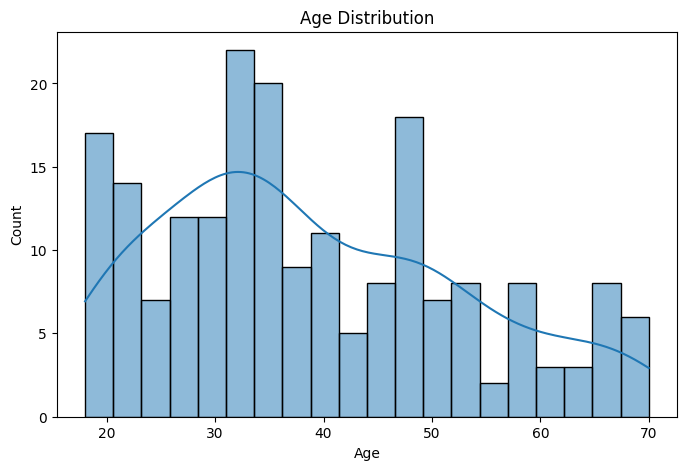

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

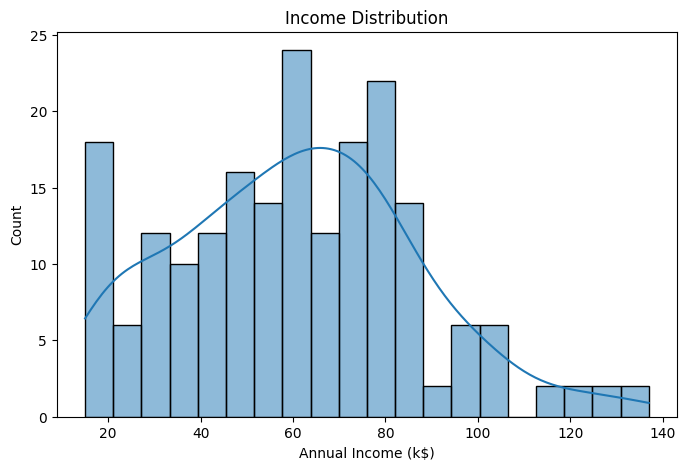

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title("Income Distribution")

plt.show()

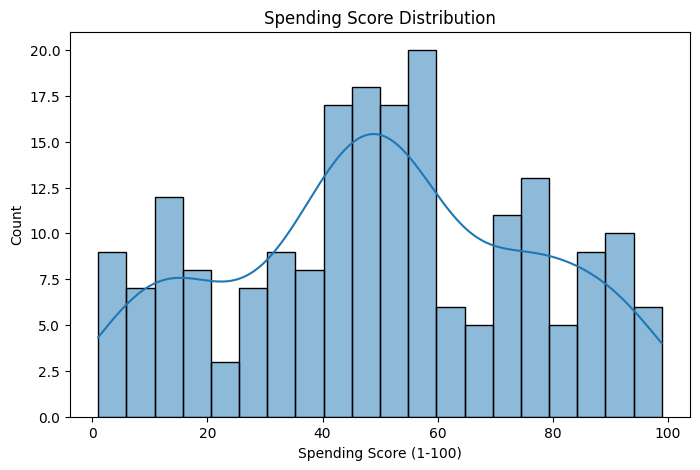

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title("Spending Score Distribution")

plt.show()

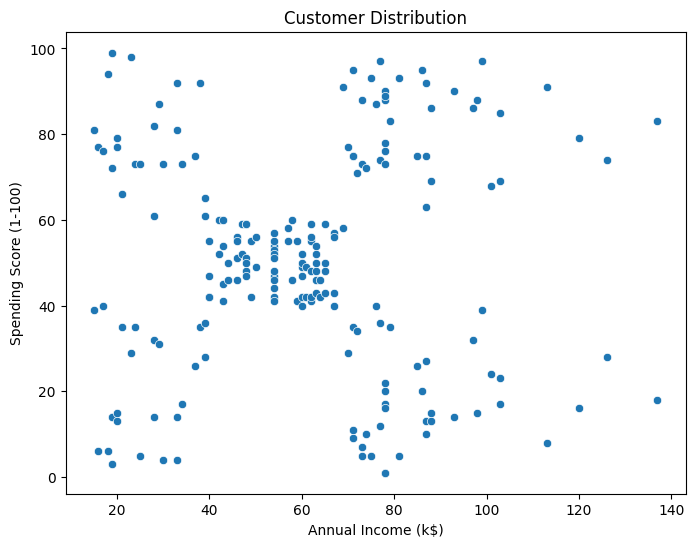

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Customer Distribution")

plt.show()

In [19]:
# Sirf Income aur Spending Score ko select kar rahe hain

X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [20]:
# StandardScaler object create kar rahe hain

scaler = StandardScaler()

# Features ko scale kar rahe hain

X_scaled = scaler.fit_transform(X)

In [21]:
# First 5 scaled rows dekhte hain

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [22]:
# ===========================================
# Step 16 : Finding Optimal K using Elbow Method
# ===========================================

wcss = []   # Har K ki inertia (WCSS) store karne ke liye empty list

# 1 se lekar 10 clusters tak check karenge
for i in range(1,11):

    # KMeans model create kar rahe hain
    kmeans = KMeans(
        n_clusters=i,          # Current number of clusters
        init='k-means++',      # Smart centroid initialization
        random_state=42,       # Same result har run me mile
        n_init=10              # Algorithm 10 baar chalega best result choose karega
    )

    # Model ko train kar rahe hain
    kmeans.fit(X_scaled)

    # Current WCSS save kar rahe hain
    wcss.append(kmeans.inertia_)

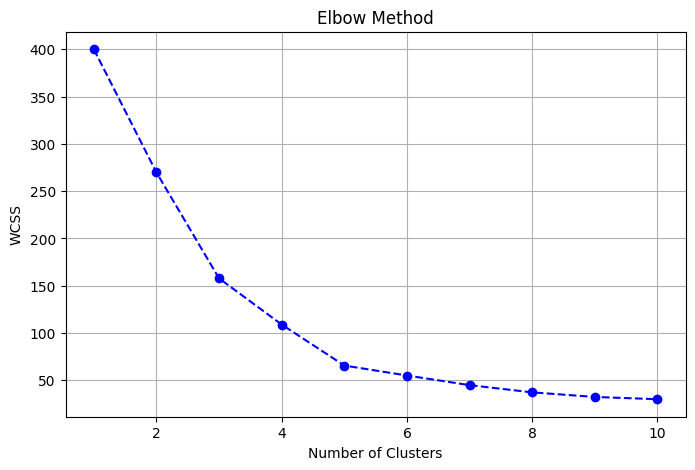

In [23]:
# ===========================================
# Plot Elbow Graph
# ===========================================

plt.figure(figsize=(8,5))

# Line plot bana rahe hain
plt.plot(
    range(1,11),      # X-axis -> Number of Clusters
    wcss,             # Y-axis -> WCSS
    marker='o',       # Har point pe circle
    linestyle='--',   # Dashed line
    color='blue'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [24]:
# ===========================================
# Step 18 : Train Final KMeans Model
# ===========================================

kmeans = KMeans(

    n_clusters=5,          # Elbow method se mila best K

    init='k-means++',      # Smart centroid initialization

    random_state=42,       # Reproducible results

    n_init=10              # Best initialization choose karega

)

In [25]:
clusters = kmeans.fit_predict(X_scaled)

In [26]:
# Cluster labels original dataset me add kar rahe hain

df['Cluster'] = clusters

In [27]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


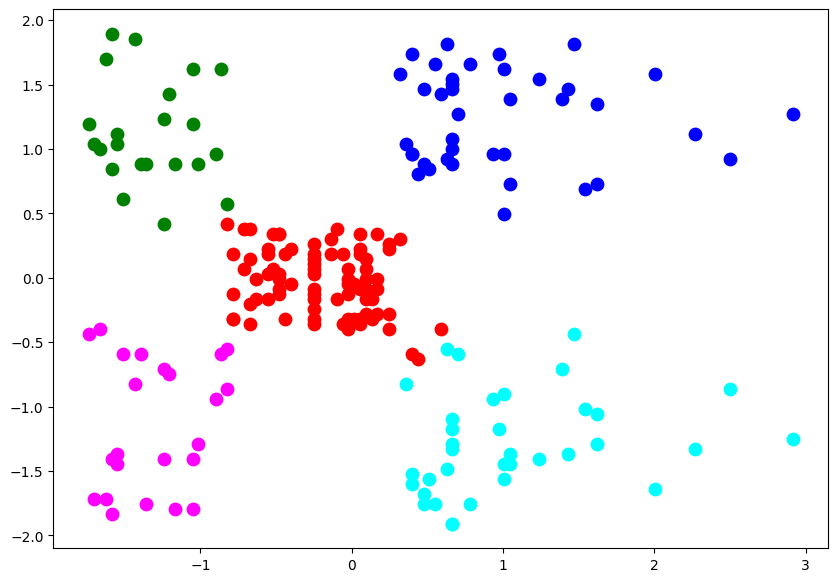

In [28]:
# ===========================================
# Step 21 : Visualize Customer Clusters
# ===========================================

# Graph ka size set kar rahe hain
plt.figure(figsize=(10,7))

# -------- Cluster 0 --------
plt.scatter(
    X_scaled[clusters == 0, 0],      # Cluster 0 ke Income values
    X_scaled[clusters == 0, 1],      # Cluster 0 ke Spending values
    s=80,                            # Dot ka size
    c='red',                         # Red colour
    label='Cluster 0'
)

# -------- Cluster 1 --------
plt.scatter(
    X_scaled[clusters == 1, 0],
    X_scaled[clusters == 1, 1],
    s=80,
    c='blue',
    label='Cluster 1'
)

# -------- Cluster 2 --------
plt.scatter(
    X_scaled[clusters == 2, 0],
    X_scaled[clusters == 2, 1],
    s=80,
    c='green',
    label='Cluster 2'
)

# -------- Cluster 3 --------
plt.scatter(
    X_scaled[clusters == 3, 0],
    X_scaled[clusters == 3, 1],
    s=80,
    c='cyan',
    label='Cluster 3'
)

# -------- Cluster 4 --------
plt.scatter(
    X_scaled[clusters == 4, 0],
    X_scaled[clusters == 4, 1],
    s=80,
    c='magenta',
    label='Cluster 4'
)

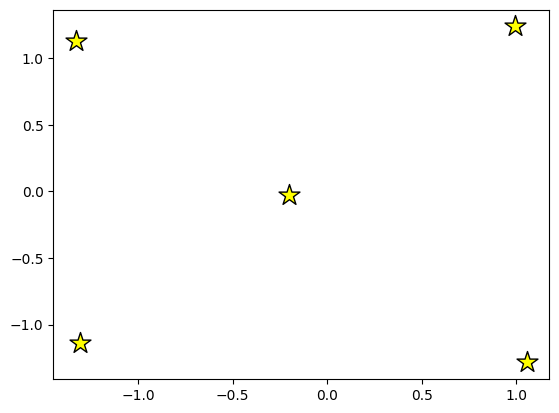

In [29]:
# ===========================================
# Plot Centroids
# ===========================================

plt.scatter(

    kmeans.cluster_centers_[:,0],   # Sabhi centroids ke X coordinates

    kmeans.cluster_centers_[:,1],   # Sabhi centroids ke Y coordinates

    s=250,                          # Size bada rakha hai

    c='yellow',                     # Yellow colour

    marker='*',                     # Star marker

    edgecolor='black',              # Black border

    label='Centroids'

)

In [31]:
# Har cluster me kitne customers hain

df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [32]:
# Har cluster ki average values

df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [33]:
# New customer ka data

new_customer = [[60,55]]

In [34]:
# Same scaler use karke scale kar rahe hain

new_customer_scaled = scaler.transform(new_customer)

In [35]:
# Cluster predict kar rahe hain

prediction = kmeans.predict(new_customer_scaled)

In [38]:
print("Predicted Cluster :", prediction)

Predicted Cluster : [0]


In [39]:
new_customer = [[60, 55]]

# Scale karo
new_customer_scaled = scaler.transform(new_customer)

# Predict
prediction = kmeans.predict(new_customer_scaled)

print("Predicted Cluster :", prediction[0])

Predicted Cluster : 0
